In [1]:
setwd("/data2/core-med1/nhadizad/nastaran/Xenotransplant/global/CLR/NEW_CLR/Rounds_v2_CLR_8/Cell_type/Ref_Standard")

In [2]:
library(stringr) #deal with string
options(stringsAsFactors = FALSE)

# --- Load Libraries without warnings/messages ---
quiet_library <- function(pkg) suppressWarnings(suppressMessages(library(pkg, character.only = TRUE)))

pkgs <- c(
  "dplyr", "zCompositions", "compositions", "reshape2", "ggplot2",
  "ggpubr", "tidyr", "tibble", "stringr", "purrr"
)

invisible(lapply(pkgs, quiet_library))

options(stringsAsFactors = FALSE)
options(future.globals.maxSize = 10 * 1024^3)


In [3]:
# 1. Load your metadata
metadata_file <- "metadata_for_clr_celltype.csv"
sample_col    <- "Sample_ID"
celltype_col  <- "cell_type"
condition_col <- "Condition_subsets"
ref_condition <- "Standard protocol"

In [4]:
meta <- read.csv("metadata_for_clr_celltype.csv")

In [12]:
# Helper Functions
get.count.matrix <- function(props, celltype_col, value_col) {
  frm <- as.formula(paste("Sample_ID", celltype_col, sep="~"))
  ct <- reshape2::acast(props, frm, value.var=value_col, fun.aggregate=mean, fill=0)
  return(ct)
}

get.proportion.matrix <- function(prop.coarse, celltype_col, pseudocount=0, 
                                 value_col="proportion", impute_zeros=TRUE, 
                                 imputation_method="cmultRepl") {
  ct <- get.count.matrix(prop.coarse, celltype_col, value_col)
  
  if (!impute_zeros) {
    ct <- ct + pseudocount
    ct <- ct / rowSums(ct)
  } else {
    all_missing <- apply(is.na(ct), 1, all)
    if (imputation_method == "cmultRepl") {
      ct[!all_missing,] <- as.matrix(zCompositions::cmultRepl(ct[!all_missing,], method="GBM"))
    }
  }
  return(ct)
}

da.by.covariate <- function(ct, celltype, condition_vec, ref_condition = NULL) {
  # 1. Explicitly set the factor levels to ensure ref_condition is the intercept
  if (!is.null(ref_condition) && ref_condition %in% condition_vec) {
    # Find the non-reference condition
    non_ref_condition <- setdiff(unique(condition_vec), ref_condition)
    # Reorder factor: ref_condition must be the first level (intercept)
    condition_vec <- factor(condition_vec, levels = c(ref_condition, non_ref_condition))
  }
  
  Z <- compositions::clr(compositions::acomp(ct))
  data <- data.frame(
    abundance = Z[,celltype],
    proportion = ct[,celltype],
    Condition = condition_vec
  )
  
  # The coefficient (smr) will now represent (Non-Ref CLR) - (Ref CLR)
  m <- lm(abundance ~ Condition, data = data)
  smr <- t(coef(summary(m))[2,])
  
  m2 <- lm(proportion ~ Condition, data = data)
  smr2 <- t(coef(summary(m2))[2,])
  colnames(smr2) <- paste("prop", colnames(smr2), sep="_")
  
  mean.prop <- mean(data$proportion)
  # NOTE: coef(m2)[1] is the mean prop of the INTERCEPT (ref_condition)
  mean.prop.ctrl <- coef(m2)[1] 
  
  return(data.frame(smr, smr2, mean.prop, mean.prop.ctrl, check.names=FALSE))
}

# Load metadata
meta <- read.csv(metadata_file)

# Prepare data
prop.coarse <- meta %>% 
  group_by(cell_type, Sample_ID, Condition_subsets) %>% 
  summarise(count = n(), .groups = 'drop')

# Generate matrices
prop_matrix <- get.proportion.matrix(
  prop.coarse, 
  celltype_col = celltype_col,
  value_col = 'count'
)
count_matrix <- get.count.matrix(
  prop.coarse, 
  celltype_col = celltype_col,
  value_col = 'count'
)

# Create analysis dataframe
analysis_df <- as.data.frame(prop_matrix) %>% 
  tibble::rownames_to_column("Sample_ID") %>% 
  left_join(distinct(meta, Sample_ID, Condition_subsets), by = "Sample_ID")

# Get conditions to test (all except the new reference: "Control")
conditions_to_test <- setdiff(unique(analysis_df$Condition_subsets), ref_condition)

# Run analysis
all_results <- list()

for (cond in conditions_to_test) {
  selected <- analysis_df %>% 
    filter(Condition_subsets %in% c(ref_condition, cond)) %>%
    filter(Sample_ID %in% rownames(count_matrix)[rowSums(count_matrix) >= 10])
  
  # Only keep cell type columns!
  cell_types <- setdiff(colnames(selected), c("Sample_ID", "Condition_subsets"))
  
  # For da.by.covariate, pass only the cell type columns and the condition vector
    # Inside your loop:
    # For da.by.covariate, pass only the cell type columns and the condition vector
    results <- lapply(cell_types, function(ct) {
      da.by.covariate(
        selected[, cell_types, drop = FALSE],
        celltype = ct,
        condition_vec = selected$Condition_subsets,
        ref_condition = ref_condition # <--- PASS THE REFERENCE HERE
      )
    })
  
  results <- do.call(rbind, results)
  rownames(results) <- cell_types
  all_results[[cond]] <- results
}


No. adjusted imputations:  7 


In [13]:

results_df <- imap_dfr(all_results, ~ {
  data.frame(
    Condition = .y,
    CellType = rownames(.x),
    PValue = .x[,"Pr(>|t|)"],
    EffectSize = .x[,"Estimate"],
    FoldChange = exp(.x[,"Estimate"]),
    MeanPropControl = .x[,"mean.prop.ctrl"],
    stringsAsFactors = FALSE
  )
}) %>%
  group_by(Condition) %>%
  mutate(FDR = p.adjust(PValue, method = "BH")) %>%
  ungroup()

In [14]:
all_results

,Estimate,Std. Error,t value,Pr(>|t|),prop_Estimate,prop_Std. Error,prop_t value,prop_Pr(>|t|),mean.prop,mean.prop.ctrl
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
CM,0.8964821,0.2833329,3.164060,1.147505e-02,0.0237559691,0.0454831096,0.5223031,6.140704e-01,0.7729839721,0.7643454379
Endocardial/lymphatic EC,1.0631344,0.4501414,2.361779,4.247738e-02,0.0008596294,0.0025542132,0.3365535,7.441680e-01,0.0101513708,0.0098387783
Endothelial cells (baboon),-2.0679814,1.0301469,-2.007463,7.563703e-02,-0.0002109420,0.0001291813,-1.6329138,1.369210e-01,0.0001379293,0.0002146355
Fibroblasts,0.9077352,0.3655063,2.483501,3.479104e-02,-0.0037638198,0.0276176266,-0.1362832,8.945971e-01,0.0767490263,0.0781176881
Lymphoids (baboon),-4.1472669,0.2818241,-14.715800,1.331835e-07,-0.0272079929,0.0102369258,-2.6578285,2.613865e-02,0.0174584275,0.0273522430
Mast cells (baboon),-2.2975127,1.0963272,-2.095645,6.558007e-02,-0.0003188910,0.0002748284,-1.1603277,2.757686e-01,0.0002058941,0.0003218544
Mural cells,1.4495507,0.1905207,7.608363,3.297905e-05,0.0110148623,0.0074070436,1.4870795,1.711648e-01,0.0247981348,0.0207927303
Myeloids (baboon),-4.6187200,0.2304956,-20.038214,8.927933e-09,-0.0593086751,0.0124892580,-4.7487749,1.045985e-03,0.0379755290,0.0595423200
Neuronal cells,1.7376527,0.2020864,8.598564,1.238185e-05,0.0038477067,0.0013837720,2.7805929,2.138004e-02,0.0049532342,0.0035540682


In [15]:
write.csv(results_df, "clr_celltype_ref_Standard.csv", row.names = FALSE)


In [16]:
our_fill_scale_gradient2 <- scale_fill_gradient2(
  limits = c(-3, 3),
  # Use the 'squish' transformer to force out-of-bounds values to the limit colors
  oob = scales::squish, 
  high = "#FF6600",   # orange
  mid = "white",
  low = "#6699FF"     # blue
)

flipx45 <- theme(axis.text.x = element_text(angle = 90, hjust = 1))

axis_format <- theme(
  axis.text.x = element_text(face = "bold"),
  axis.text.y = element_text(face = "bold"),
  axis.title.x = element_text(face = "bold"),
  axis.title.y = element_text(face = "bold")
)



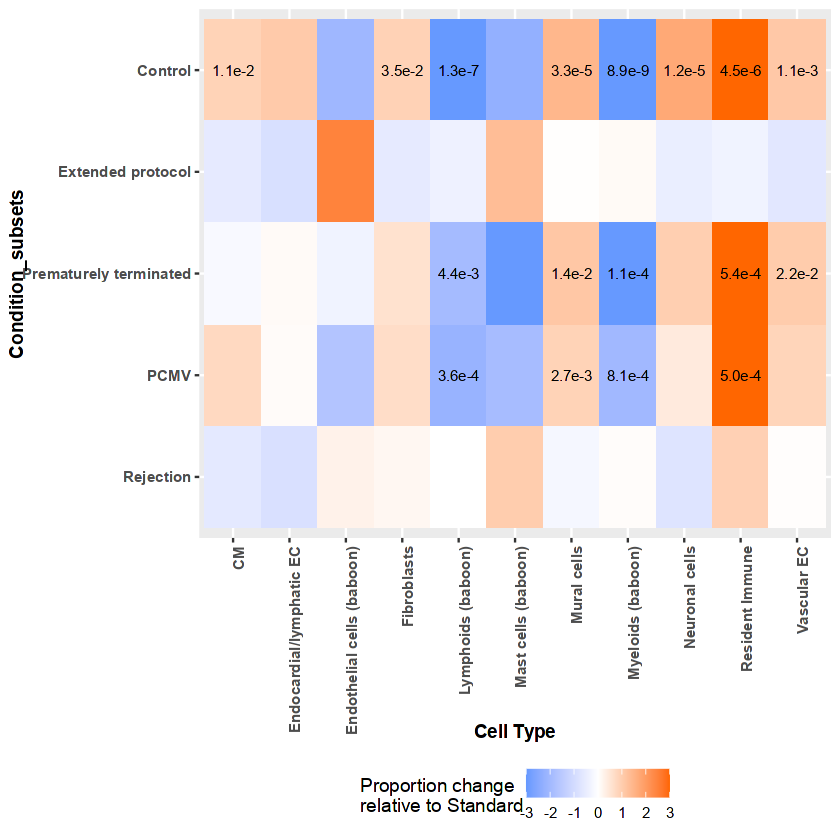

In [17]:

results_df$FDR_plot <- results_df$FDR


# Define the desired order of conditions
condition_order <- c( "Rejection","PCMV", "Prematurely terminated", "Extended protocol", "Control")

# Convert Condition to factor with specified levels before plotting
results_df$Condition <- factor(results_df$Condition, levels = condition_order)

# Now create the plot with the ordered conditions
p1 <- ggplot(results_df, aes(x = CellType, y = Condition, fill = EffectSize)) +
  geom_tile() +
  our_fill_scale_gradient2 +
  labs(
    y = "Condition_subsets",
    x = "Cell Type",
    fill = "Proportion change\nrelative to Standard"
  ) +
  theme(
    legend.position = "bottom",
    axis.text.x = element_text(angle = 90, hjust = 1, face = "bold"),
    axis.text.y = element_text(face = "bold"),
    axis.title.x = element_text(face = "bold"),
    axis.title.y = element_text(face = "bold")
  ) +
  # Add p-value for significant cells only
  geom_text(
    data = subset(results_df, FDR_plot < 0.05),
    aes(label = gsub("e-0", "e-", formatC(PValue, format = "e", digits = 1))),
    color = "black", size = 3
  )

# Save with reduced height
# ggsave("p1_heatmap_plot.pdf", plot = p1, width = 6, height = 4.3, units = "in")

ggsave("heatmap.pdf", plot = p1, width = 6, height = 4.3, units = "in", dpi = 300)
p1




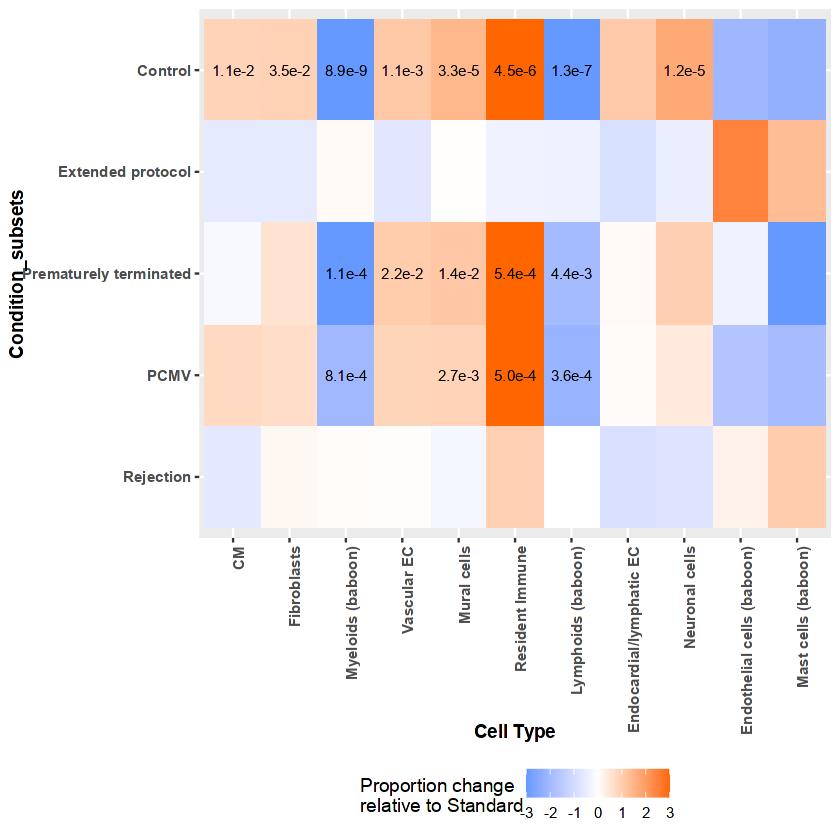

In [18]:
results_df$FDR_plot <- results_df$FDR


# Define the desired order of conditions
condition_order <- c( "Rejection","PCMV", "Prematurely terminated", "Extended protocol", "Control")

# Define the desired order of cell types (NEW)
celltype_order <- c(
  "CM", "Fibroblasts", "Myeloids (baboon)", "Vascular EC", "Mural cells",
  "Resident Immune", "Lymphoids (baboon)", "Endocardial/lymphatic EC",
  "Neuronal cells", "Endothelial cells (baboon)", "Mast cells (baboon)"
)

# Convert Condition to factor with specified levels
results_df$Condition <- factor(results_df$Condition, levels = condition_order)

# Convert CellType to factor with specified levels (THE REQUIRED CHANGE)
results_df$CellType <- factor(results_df$CellType, levels = celltype_order)


# Now create the plot with the ordered conditions and cell types
p1 <- ggplot(results_df, aes(x = CellType, y = Condition, fill = EffectSize)) +
  geom_tile() +
  our_fill_scale_gradient2 +
  labs(
    y = "Condition_subsets",
    x = "Cell Type",
    fill = "Proportion change\nrelative to Standard"
  ) +
  theme(
    legend.position = "bottom",
    axis.text.x = element_text(angle = 90, hjust = 1, face = "bold"),
    axis.text.y = element_text(face = "bold"),
    axis.title.x = element_text(face = "bold"),
    axis.title.y = element_text(face = "bold")
  ) +
  # Add p-value for significant cells only (FDR < 0.05)
  geom_text(
    data = subset(results_df, FDR_plot < 0.05),
    aes(label = gsub("e-0", "e-", formatC(PValue, format = "e", digits = 1))),
    color = "black", size = 3
  )

# Save the plot
ggsave("heatmap_reordered.pdf", plot = p1, width = 6, height = 4.3, units = "in", dpi = 300)
p1

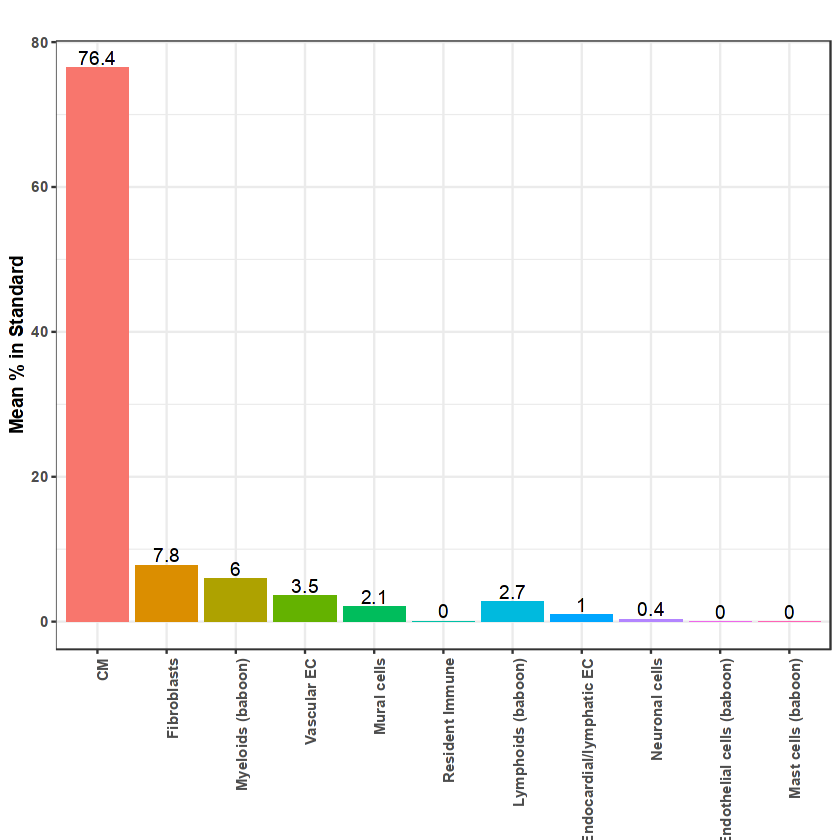

In [19]:
# Define the desired order of cell types (Needed for ordering the plot)
celltype_order <- c(
  "CM", "Fibroblasts", "Myeloids (baboon)", "Vascular EC", "Mural cells",
  "Resident Immune", "Lymphoids (baboon)", "Endocardial/lymphatic EC",
  "Neuronal cells", "Endothelial cells (baboon)", "Mast cells (baboon)"
)

# Use only the first tested condition's values for each cell type (should be same for all conditions)
control_means <- results_df %>%
  group_by(CellType) %>%
  summarise(MeanPropControl = first(MeanPropControl), .groups = 'drop')

# --- Apply the desired CellType order to the control_means data frame (THE REQUIRED CHANGE) ---
control_means$CellType <- factor(control_means$CellType, levels = celltype_order)

# Create the plot
p2 <- ggplot(control_means, aes(x = CellType, y = MeanPropControl * 100, fill = CellType)) +
  geom_bar(stat = "identity") +
  geom_text(aes(label = round(MeanPropControl * 100, 1)), vjust = -0.2, size = 4) +
  labs(title = "", y = "Mean % in Standard", x = "Cell Type") +
  theme_bw() +
  theme(axis.text.x = element_text(angle = 90, hjust = 1, face = "bold"),
        axis.text.y = element_text(face = "bold"),
        axis.title.x = element_blank(),
        legend.position = "none",
        axis.title.y = element_text(face = "bold")) +
  # Using scale_x_discrete(drop = FALSE) is good practice to ensure all levels are shown
  scale_x_discrete(drop = FALSE)

ggsave("Barplot_ref_standard_mean_proportions.pdf", plot = p2, width = 6, height = 4.3, units = "in", dpi = 300)
print(p2)

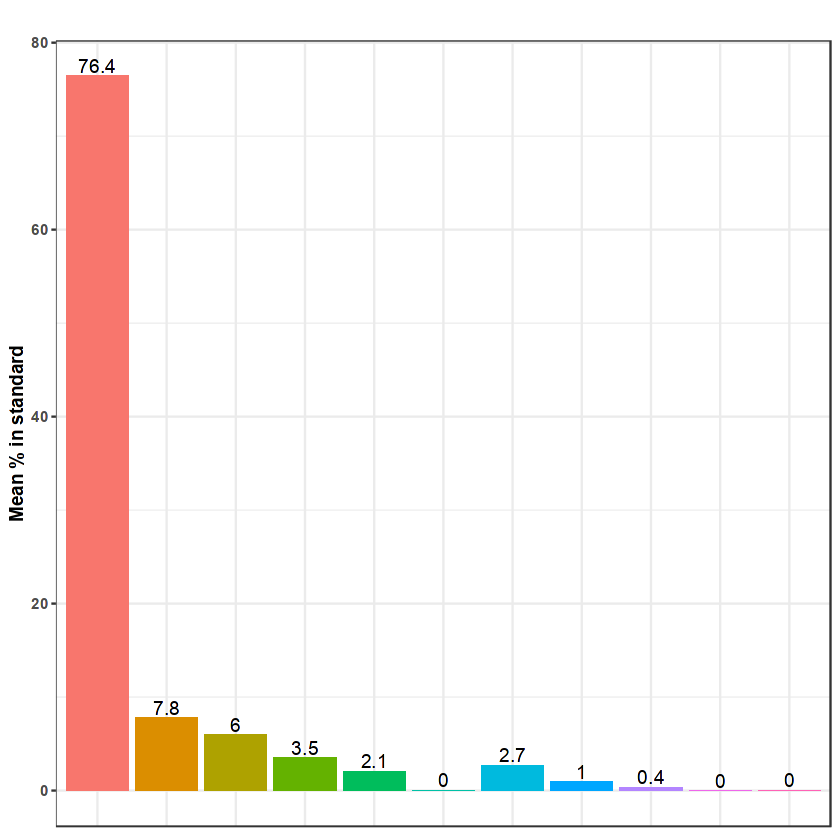

In [20]:
p3 <- ggplot(control_means, aes(x = CellType, y = MeanPropControl * 100, fill = CellType)) +
  geom_bar(stat = "identity") +
  geom_text(aes(label = round(MeanPropControl * 100, 1)), vjust = -0.2, size = 4) +
  labs(title = "", y = "Mean % in standard") +
  theme_bw() +
  # REMOVE X-AXIS
  theme(
    axis.title.x = element_blank(),
    axis.text.x = element_blank(),
    axis.ticks.x = element_blank(),
    axis.text.y = element_text(face = "bold"),
    axis.title.y = element_text(face = "bold"),
    legend.position = "none"
  ) +
  scale_x_discrete(drop = FALSE)

ggsave("noname_barplot_standard_as_ref.pdf", plot = p3, width = 6, height = 4, units = "in", dpi = 300)
p3


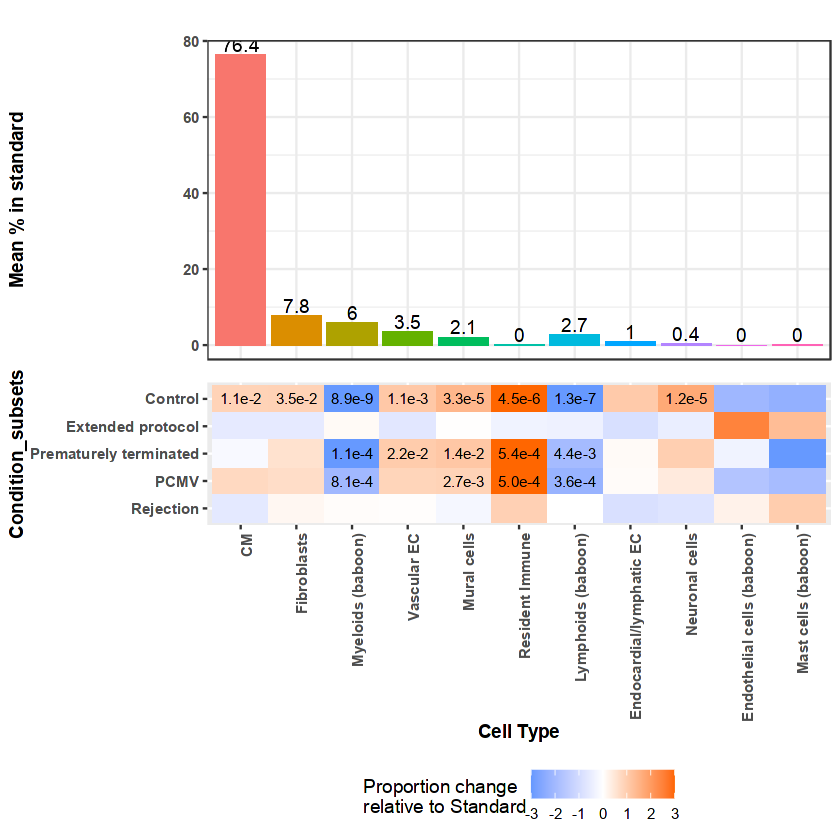

In [21]:
###### If not installed: install.packages("ggpubr")
library(ggpubr)

plot_all <- ggarrange(
  p3, p1,
  ncol = 1, nrow = 2,
  align = "v",
  heights = c(4, 5)  # You can adjust these numbers for desired proportions
)

# Print in RStudio/viewer
plot_all

# Save as PDF
ggsave("Final_CLR_celltype_standard_ref.pdf", plot = plot_all,
       width = 7, height = 8, units = "in", dpi = 400)
